In [63]:
import pandas as pd

1. Data Preparation


In [64]:
df = pd.read_csv('./data/dataset.csv')
df.head()


,Unnamed: 0,id,created_on,title,description,tag
0,0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


In [65]:
from sklearn.model_selection import train_test_split

In [66]:
df.tag.value_counts()

tag
natural-language-processing    310
computer-vision                285
other                          106
mlops                           63
Name: count, dtype: int64

In [67]:
test_size=0.2
train_df, val_df = train_test_split(df, stratify=df.tag, test_size=test_size,random_state=1980)

In [68]:
val_df.tag.value_counts() * int((1-test_size) / test_size)


tag
natural-language-processing    248
computer-vision                228
other                           84
mlops                           52
Name: count, dtype: int64

In [69]:
val_df.tag.value_counts()

tag
natural-language-processing    62
computer-vision                57
other                          21
mlops                          13
Name: count, dtype: int64

2. Data Exploration (EDA)


In [70]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import warnings; warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS

In [71]:
all_tags = Counter(df.tag)
all_tags.most_common()

[('natural-language-processing', 310),
 ('computer-vision', 285),
 ('other', 106),
 ('mlops', 63)]

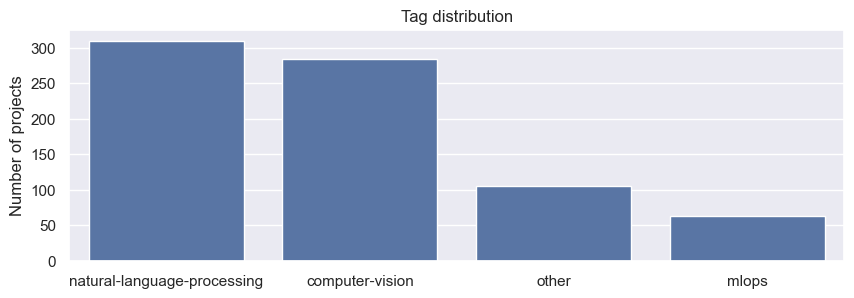

In [72]:
tags,tag_counts=zip(*all_tags.most_common())
plt.figure(figsize=(10,3))
ax=sns.barplot(x=list(tags),y=list(tag_counts))
ax.set_xticklabels(tags)
plt.title("Tag distribution")
plt.ylabel("Number of projects")
plt.show()

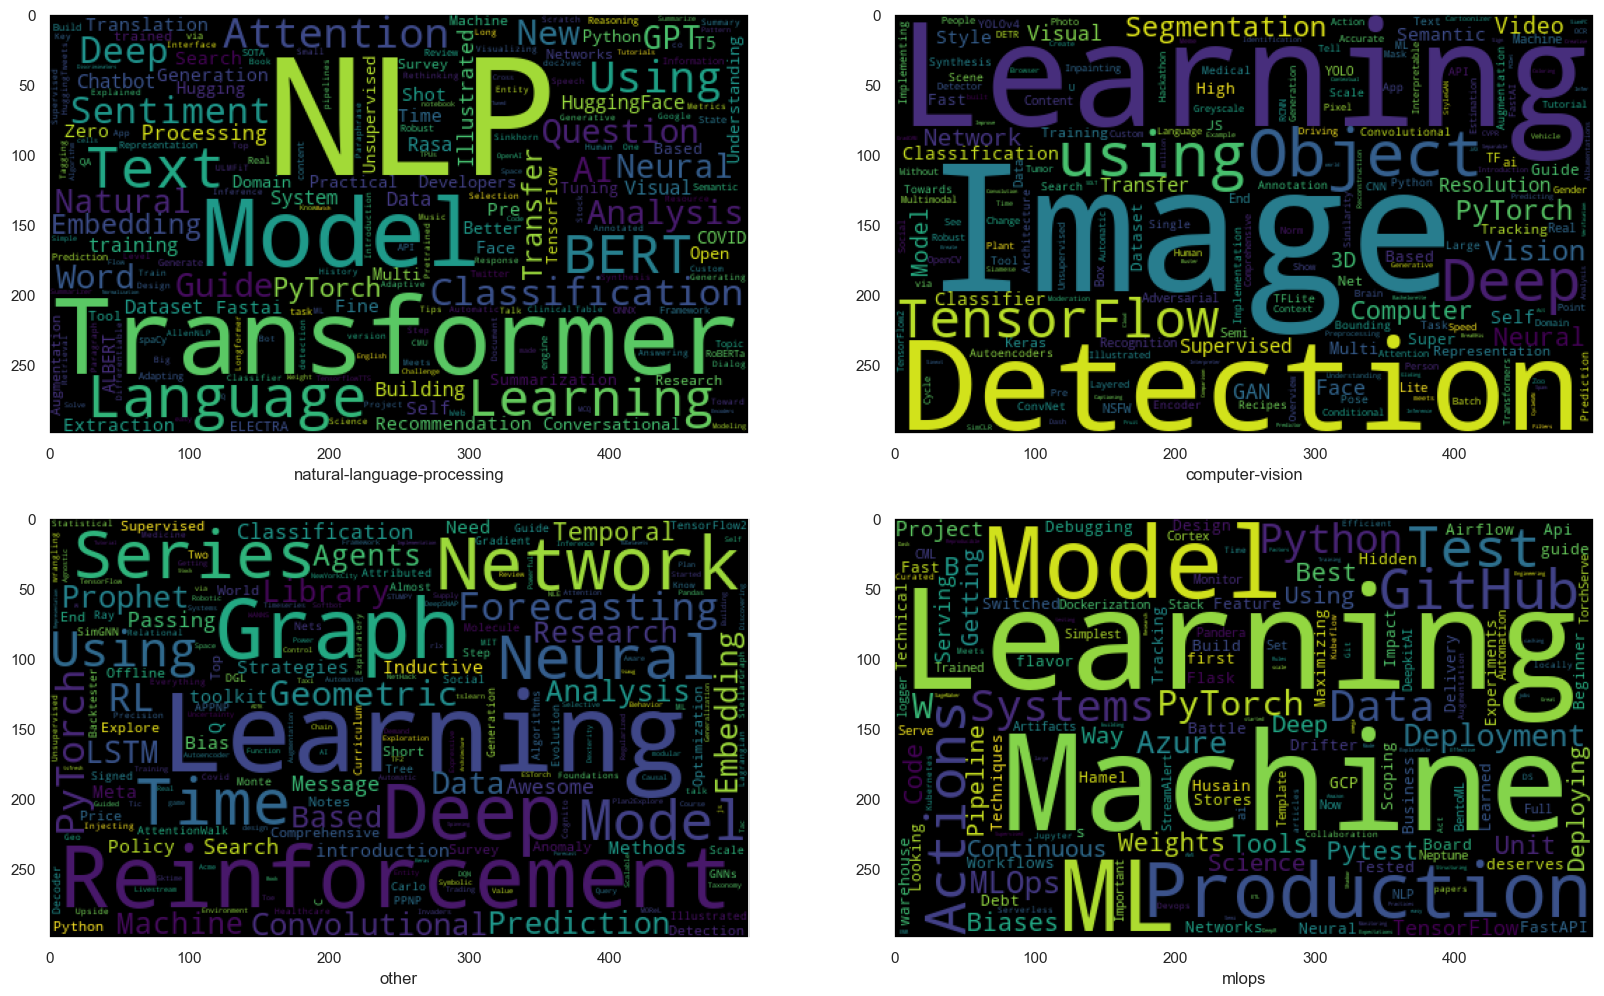

In [73]:
# Most frequent tokens for each tag
plt.figure(figsize=(20, 12))
for id,tag in enumerate(tags):
    plt.subplot(2,2,id+1)

    subset = df[df.tag==tag]
    text = subset.title.values
    cloud = WordCloud(
        stopwords=STOPWORDS, background_color="black", collocations=False,
        width=500, height=300).generate(" ".join(text))
    plt.xlabel(tag)
    plt.grid(False)
    plt.axis('on')
    plt.imshow(cloud)

3. Data Preprocessing


In [74]:
import json
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re



In [75]:
df['content'] = df.title+' '+df.description 

In [76]:
nltk.download('stopwords')
STOPWORDS=stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [77]:
def clean_text(text, stopwords=STOPWORDS):
    text=text.lower()
    pattern=re.compile(r'\b('+'|'.join(stopwords)+')\b\s')
    text=pattern.sub('',text)
    text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing
    text = re.sub("[^A-Za-z0-9]+", " ", text)  # remove non alphanumeric chars
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()  # strip white space at the ends
    text = re.sub(r"http\S+", "", text)  #  remove links

    return text

In [78]:
original_df=df.copy()
df.content=df.content.apply(clean_text)
print (f"{original_df.content.values[0]}\n{df.content.values[0]}")

Comparison between YOLO and RCNN on real world videos Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.
comparison between yolo and rcnn on real world videos bringing theory to experiment is cool we can easily train models in colab and find the results in minutes


In [79]:
df=df.drop(['id','Unnamed: 0', 'created_on','title','description'],axis=1,errors='ignore')
df=df.dropna(subset='tag')
cols=list(df.columns)
cols.append(cols.pop(cols.index('tag')))
df=df[cols]
df.head()

,content,tag
0,comparison between yolo and rcnn on real world...,computer-vision
1,show infer tell contextual inference for creat...,computer-vision
2,awesome graph classification a collection of i...,other
3,awesome monte carlo tree search a curated list...,other
4,attentionwalk a pytorch implementation of watc...,other


In [80]:
tags=train_df.tag.unique().tolist()
num_classes=len(tags)
class_to_index={tag:i for i,tag in enumerate(tags)}
class_to_index

{'natural-language-processing': 0,
 'computer-vision': 1,
 'other': 2,
 'mlops': 3}

In [81]:
#Encode labels
df["tag"]=df.tag.map(class_to_index)
df

,content,tag
0,comparison between yolo and rcnn on real world...,1
1,show infer tell contextual inference for creat...,1
2,awesome graph classification a collection of i...,2
3,awesome monte carlo tree search a curated list...,2
4,attentionwalk a pytorch implementation of watc...,2
...,...,...
759,a survey of the state of explainable ai for nl...,0
760,topic modeling with bert leveraging transforme...,0
761,openmmlab computer vision mmcv is a python lib...,1
762,machine learning methods explained examples mo...,2


In [82]:
def decode(indices):
    return [tags[index] for index in indices]
decode(df.head(10).tag.values)

['computer-vision',
 'computer-vision',
 'other',
 'other',
 'other',
 'other',
 'other',
 'other',
 'other',
 'computer-vision']

In [2]:
#Tokenizer
import os
import numpy as np
from transformers import BertTokenizer

In [6]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
BERT_TOKENIZER = os.environ["BERT_TOKENIZER"]

In [8]:
# Bert tokenizer
tokenizer = BertTokenizer.from_pretrained(BERT_TOKENIZER, return_dict=False)
text = "Transfer learning with transformers for text classification learning right."
encoded_inputs = tokenizer([text], return_tensors="np", padding="longest")  # pad to longest item in batch
print ("input_ids:", encoded_inputs["input_ids"])
print ("attention_mask:", encoded_inputs["attention_mask"])
print (tokenizer.decode(encoded_inputs["input_ids"][0]))
#input ids: index of each token in the vocabulary

input_ids: [[  102  2268  1904   190 29155   168  3267  2998  1904  2083   205   103]]
attention_mask: [[1 1 1 1 1 1 1 1 1 1 1 1]]
[CLS] transfer learning with transformers for text classification learning right. [SEP]


In [85]:
def tokenize(batch, tokenizer):
    encoded_inputs=tokenizer(batch.content.tolist(), return_tensors='np',padding='longest')
    return {'ids':encoded_inputs["input_ids"],
            'masks':encoded_inputs["attention_mask"],
            'targets':np.array(batch.tag)}
tokenize(df,tokenizer)

{'ids': array([[ 102, 2029,  467, ...,    0,    0,    0],
        [ 102,  405, 4920, ...,    0,    0,    0],
        [ 102, 9559,  123, ...,    0,    0,    0],
        ...,
        [ 102, 1937, 2561, ...,    0,    0,    0],
        [ 102, 3997, 1904, ...,    0,    0,    0],
        [ 102, 9461, 3732, ...,    0,    0,    0]], shape=(764, 55)),
 'masks': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(764, 55)),
 'targets': array([1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 0, 3, 1, 1, 1,
        0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 1, 0, 3, 1, 0, 1, 0, 2, 1,
        2, 1, 1, 3, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 2, 0, 2, 1, 0, 1, 1, 2,
        2, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 3, 3, 0, 0, 0, 0, 2, 2, 2, 1,
        0, 0, 1, 1, 0, 1, 3, 0, 1, 

4. Distributed Data Processing


In [86]:
import ray
from ray.data import Dataset
from typing import Dict, List, Tuple
if ray.is_initialized():
    ray.shutdown()
context=ray.init(num_cpus=2)
print(context.dashboard_url)
ray.data.DatasetContext.get_current().execution_options.preserve_order = True  # deterministic


2026-03-25 10:04:22,756	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


127.0.0.1:8265


In [87]:
ds=ray.data.read_csv('./data/dataset.csv')
ds=ds.random_shuffle(seed=1980)
ds.take(1)

2026-03-25 10:04:24,446	INFO logging.py:392 -- Registered dataset logger for dataset dataset_2_0
2026-03-25 10:04:24,447	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_2_0. Full logs are in C:\Users\admin\AppData\Local\Temp\ray\session_2026-03-25_10-04-16_867466_27276\logs\ray-data
2026-03-25 10:04:24,454	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_2_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> LimitOperator[limit=1]
2026-03-25 10:04:25,187	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_2_0 =======
2026-03-25 10:04:25,187	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-03-25 10:04:25,187	INFO logging_progress.py:227 -- Active & requested resources: 0/2 CPU, 0.0B/366.9MiB object store
2026-03-25 10:04:25,195	INFO logging_progress.py:181 -- 
2026-03-25 10:04:25,196	INFO logging_progress.py:231 -- ReadCSV->SplitBlocks(4): 0/1
2026-03-25 10:04:25,197	INFO logging_p

[{'': 597,
  'id': 1953,
  'created_on': datetime.datetime(2020, 7, 24, 6, 30, 44),
  'title': 'BentoML',
  'description': 'BentoML is an open-source framework for high-performance ML model serving.',
  'tag': 'mlops'}]

In [88]:
"""dataflow: the data is grouped by the column 'stratify', and ray sends each group to a worker to tag.
after that we have 1 unify tagged dataset, ray distributes the computing randomly accross workers"""
def stratify_split(
    ds: Dataset,
    stratify: str, #column name to stratify
    test_size: float,
    shuffle: bool = True,
    seed: int = 1980,
) -> Tuple[Dataset, Dataset]:
    def _add_split(df: pd.DataFrame)->pd.DataFrame:
        train_df,test_df=train_test_split(df,test_size=test_size,shuffle=shuffle,random_state=seed)
        train_df['_split']='train'
        test_df['_split']='test'
        return pd.concat([train_df,test_df])
    def _filter_split(df: pd.DataFrame, split: str)->pd.DataFrame:
        return df.loc[df['_split']==split].drop(columns=['_split'],axis=1)
    #map_groups, map_batches, map
    grouped=ds.groupby(stratify).map_groups(_add_split,batch_format='pandas')
    #grouped=grouped.materialize()#materialize forces ray to cache the result so it wont run groupby twice which is crazy expensive
    train_ds, test_ds=[grouped.map_batches(_filter_split,fn_kwargs={'split':split},batch_format='pandas') for split in ['train','test']]
    if shuffle:
        train_ds=train_ds.random_shuffle(seed=seed)
        test_ds=test_ds.random_shuffle(seed=seed)

    return train_ds, test_ds

In [89]:
import sys
sys.path.append('..')


In [90]:
nltk.download('stopwords')
STOPWORDS=stopwords.words('english')
import numpy as np
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
pattern=re.compile(r'\b('+'|'.join(STOPWORDS)+')\b\s')
def clean_text(text, stopwords=STOPWORDS):
    text=text.lower()    
    text=pattern.sub('',text)
    text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing
    text = re.sub("[^A-Za-z0-9]+", " ", text)  # remove non alphanumeric chars
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()  # strip white space at the ends
    text = re.sub(r"http\S+", "", text)  #  remove links
    return text

class_to_index={tag:i for i,tag in enumerate(ds.unique('tag'))}
def ultimate_preprocessing(df: pd.DataFrame)->pd.DataFrame:
    df=df.dropna(subset=['tag'])
    df['title']=df['title'].fillna('')
    df['description']=df['description'].fillna('')
    df['content'] = df.title+' '+df.description 
    
    df['content']=df['content'].apply(clean_text)
    df=df.drop(['id','Unnamed: 0', 'created_on','title','description'],axis=1,errors='ignore')
    cols=list(df.columns)
    cols.append(cols.pop(cols.index('tag')))
    df=df[cols]
    tags=df.tag.unique().tolist()
    
    df["tag"]=df.tag.map(class_to_index)
    return df
def tokenize(batch, tokenizer):
    encoded_inputs=tokenizer(batch.content.tolist(), return_tensors='np',padding='longest')
    return {'ids':encoded_inputs["input_ids"],
            'masks':encoded_inputs["attention_mask"],
            'targets':np.array(batch.tag)}

cleaned_ds=ds.map_batches(ultimate_preprocessing,batch_format='pandas')

train_ds, test_ds=stratify_split(cleaned_ds,'tag', 0.2)

train_ds=train_ds.map_batches(tokenize,fn_kwargs={'tokenizer':tokenizer}, batch_format='pandas')
test_ds=test_ds.map_batches(tokenize,fn_kwargs={'tokenizer':tokenizer}, batch_format='pandas')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-03-25 10:04:28,729	INFO logging.py:392 -- Registered dataset logger for dataset dataset_4_0
2026-03-25 10:04:28,729	INFO hash_aggregate.py:161 -- Estimated memory requirement for aggregating aggregator (partitions=1, aggregators=1, dataset (estimate)=0.0GiB): shuffle=0.1MiB, output=0.1MiB, total=0.3MiB, 
2026-03-25 10:04:28,737	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_4_0. Full logs are in C:\Users\admin\AppData\Local\Temp\ray\session_2026-03-25_10-04-16_867466_27276\logs\ray-data
2026-03-25 10:04:28,747	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_4_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> HashAggregateOperator[HashAggregate(key_columns=(), num_partitions=1)] -> LimitOperator[limit=1]
2026-03-25 10:04:28,779	INFO lo

In [92]:
train_ds.write_parquet("local_data/train_v1")
test_ds.write_parquet("local_data/test_v1")

2026-03-25 10:04:41,413	INFO logging.py:392 -- Registered dataset logger for dataset dataset_17_0


2026-03-25 10:04:41,445	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_17_0. Full logs are in C:\Users\admin\AppData\Local\Temp\ray\session_2026-03-25_10-04-16_867466_27276\logs\ray-data
2026-03-25 10:04:41,448	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_17_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadCSV] -> AllToAllOperator[RandomShuffle] -> TaskPoolMapOperator[MapBatches(ultimate_preprocessing)] -> HashShuffleOperator[Shuffle(key_columns=('tag',), num_partitions=200)] -> AllToAllOperator[MapBatches(_add_split)->MapBatches(_filter_split)->RandomShuffle] -> TaskPoolMapOperator[MapBatches(tokenize)->Write]
(raylet) Windows fatal exception: Windows fatal exception: access violation
(raylet) 
(raylet) access violation
(raylet) 
2026-03-25 10:04:41,498	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_17_0 =======
2026-03-25 10:04:41,503	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-03-25 10:04:41,505	INFO 

In [93]:
ray.shutdown()